Bring in necessary imports

In [2]:
using Revise

using LinearAlgebra
using Random
using Statistics
using Printf

using Plots

using DifferentialEquations
import StochasticDiffEq as SDE

using Optim
using Optimisers
using Optimization
using OptimizationOptimisers

using ForwardDiff
using DiffResults

using ModelingToolkit
using Symbolics
using NeuralPDE

using Lux
using LuxCUDA
using Flux

using ComponentArrays
using IntervalSets

# Problem Setup
Consider a problem where there is some "thing" (such as fish, crops, etc) that grows with time that we need to strategically "harvest" to sell for a reward.

If we harvest too much, we'll set us up for failure later. If we harvest too little, we leave performance on the table.

We formulate this as the following optimal control problem:
$$
\max R = \mathbb{E}\left[ \int_{0}^{\infty} e^{- \rho t} x_t \left(1 - e^{- \alpha u_t} \right) dt \right]
$$

subject to the dynamics:
$$
dx_{t} = (r x_t - u_t) dt + \sigma x_t dW_t
$$

where $x$ represents the "thing", $u$ represents our harvesting rate (our control), $r$ represents the growth rate, $\sigma$ represents the volatility associated with the "noise" process (which is where the stochasticity enteres the system), $\rho$ represents the discount rate for the objective, and $\alpha$ represents the sensitivity of the reward to the harvesting rate.

In [3]:
# Define parameters
mutable struct Params
    α::Float64      # Reward sensitivity
    ρ::Float64      # Objective discount rate
    r::Float64      # growth rate
    σ::Float64      # volatility
    u_ctrl::Float64 # control variable (initially set to 0, will be optimized)
end

params = Params(0.5, 0.3, 0.15, 0.1, 0.0)

# Define the SDE dynamics
function drift!(du, u, p, t)
    du[1] = p.r * u[1] - p.u_ctrl
end

function diffusion!(du, u, p, t)
    du[1] = p.σ * u[1]
end

diffusion! (generic function with 1 method)

# HJB Solving
To find the optimal control, we must satisfy the HJB equation. We derive the HJB equation below.

We know the value function must satisfy:
$$
V(x) = \sup_{u_t} \mathbb{E}_{x} \left[ \int_{0}^{\infty} e^{-\rho t} x_t \left( 1 - e^{- \alpha u_t} \right) dt \right]
$$

and the associated HJB condition is given by:
$$
\rho V(x) = \max_{u} \left\{ x(1-e^{-\alpha u}) + (rx-u)V_{x}(x) + \frac{1}{2} \sigma^2 x^2 V_{xx}(x) \right\}
$$

We can solve for the optimal control by setting up the Hamiltonian:
$$
H(x,u,p) = x\left(1-e^{- \alpha u}\right) + (rx-u)V_{x}(x)
$$

and solving for $u^*$ as follows:
$$
\begin{align*}
\frac{\partial H}{\partial u} &= \alpha x e^{- \alpha u} - V_{x} = 0\\
V_x &= \alpha x e^{\alpha u^*}\\
u^*(x) &= - \frac{1}{\alpha} \ln \left( \frac{V_{x}(x)}{\alpha x} \right)
\end{align*}
$$

Substituting this back into the HJB expression:
$$
\rho V = x - \frac{V_x}{\alpha} + rx V_x + \frac{V_x}{\alpha} \ln \left( \frac{V_x}{\alpha x} \right) + \frac{1}{2} \sigma^2 x^2 V_{xx}
$$

We now explore various methods of satisfying this HJB equation in order to achieve the optimal control.

## Adaptive Dynamic Programming


We provide a basis function to approximate the form of the solution. We choose to use:
$$
V(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3
$$
as our estimated form. ADP seeks to identify the values of theta that best satisfy the HJB condition.

In [ ]:
# Basis function for approximation and associated derivatives
function V(x, θ)
    return θ[1] + θ[2]*x + θ[3]*x^2 + θ[4]*x^3
end

function Vx(x, θ)
    return θ[2] + 2θ[3]*x + 3θ[4]*x^2
end

function Vxx(x, θ)
    return 2θ[3] + 6θ[4]*x
end

# Policy derived from the value function approximation
function policy(x, θ, α)
    z = Vx(x, θ)/(α*x)
    z = clamp(z, 1e-8, 0.999)

    return -(1/α)*log(z)
end

# HJB residual function to evaluate the approximation quality
function hjb_residual(x, θ, p)
    u = policy(x, θ, p.α)
    lhs = p.ρ * V(x, θ)
    rhs = x*(1-exp(-p.α*u)) + (p.r*x-u)*Vx(x, θ) + 0.5*p.σ^2*x^2*Vxx(x, θ)

    return lhs - rhs
end

# Define loss function for optimization
function loss(θ, params, xtrain)
    return mean(hjb_residual(x, θ, params)^2 for x in xtrain)
end

hjb_residual (generic function with 1 method)

Now we sample a representative state space and optimize/solve for the parameters.

In [ ]:
# Sample points for training the value function approximation
xtrain = collect(range(0.1, 10.0, length=200))

# Initial guess for θ
theta_guess = [0.0, 0.1, 0.0, 0.0] # starting with linear approximation

# Optimize the parameters of the value function approximation
res = optimize(θ -> loss(θ, params, xtrain), theta_guess, BFGS())
theta_opt = Optim.minimizer(res)

4-element Vector{Float64}:
 -0.009990642130169371
  0.028212017527803075
  0.24809865575778933
 -0.007019700177859839

Now we simulate the system with the learned policy

In [6]:
mutable struct ADPParams
    α::Float64
    ρ::Float64
    r::Float64
    σ::Float64
    θ::Vector{Float64}
end

# Define the drift and diffusion functions for the ADP simulation
function drift_adp!(du, u, p, t)
    x = u[1]
    harvest = policy(x, p.θ, p.α)
    du[1] = p.r*x - harvest
    return du
end

function diffusion_adp!(du, u, p, t)
    du[1] = p.σ * u[1]
    return du
end


# Define parameters for simulation
adp_params = ADPParams(params.α, params.ρ, params.r, params.σ, theta_opt)

# Define initial condition and time span for ADP simulation
u0 = [1.0]
tspan = (0.0, 10.0)

# Simulate the system using the derived policy
prob = SDEProblem(drift_adp!, diffusion_adp!, u0, tspan, adp_params)
sol = solve(prob, SDE.EM(), dt=0.01)

retcode: Success
Interpolation: 1st order linear
t: 1001-element Vector{Float64}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.060000000000000005
  0.07
  0.08
  0.09
  0.09999999999999999
  0.10999999999999999
  0.11999999999999998
  ⋮
  9.889999999999834
  9.899999999999833
  9.909999999999833
  9.919999999999833
  9.929999999999833
  9.939999999999833
  9.949999999999832
  9.959999999999832
  9.969999999999832
  9.979999999999832
  9.989999999999831
 10.0
u: 1001-element Vector{Vector{Float64}}:
 [1.0]
 [1.0013664385904446]
 [0.9850645949436662]
 [0.9856373921750026]
 [0.9819151601500248]
 [0.9705154093692174]
 [0.9835560988854731]
 [0.9851685310097533]
 [0.9938519784250843]
 [1.007879030900781]
 [1.0111825686716227]
 [1.0003375820180092]
 [0.9976918849687241]
 ⋮
 [1.9375815665584581]
 [1.9488031898483267]
 [1.912384420117829]
 [1.9396216446814512]
 [1.9381794396598013]
 [1.9452328456635668]
 [1.934115010393535]
 [1.9082769323446023]
 [1.8744473074918162]
 [1.8705104729184787]
 [1.8

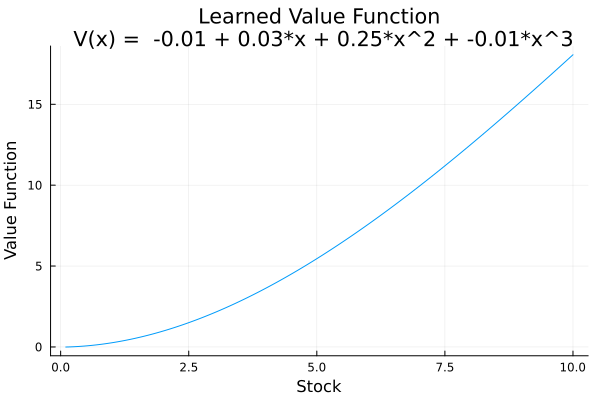

In [7]:
# Plot the learned value function approximation
xvals = collect(range(0.1, 10.0, length=200))
v_vals = [V(x, theta_opt) for x in xvals]
rounded_thetas = round.(theta_opt, digits=2)
plot(xvals, v_vals, 
    title="Learned Value Function\n $V(x) =  $(rounded_thetas[1]) + $(rounded_thetas[2])*x + $(rounded_thetas[3])*x^2 + $(rounded_thetas[4])*x^3",
    xlabel="Stock", ylabel="Value Function", legend=false)

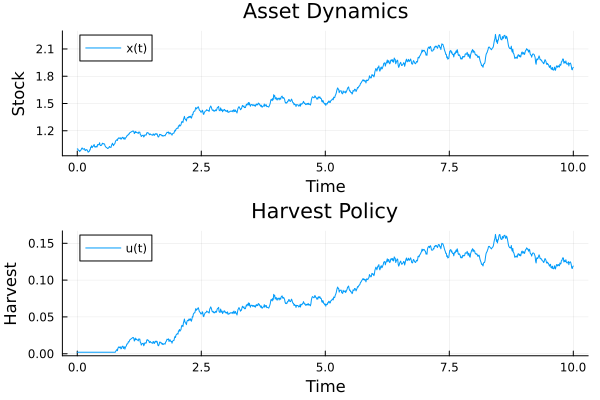

In [8]:
xvals = first.(sol.u)
uvals = [policy(x, theta_opt, adp_params.α) for x in xvals]
adp_asset_plot = plot(sol.t, xvals, title="Asset Dynamics", xlabel="Time", ylabel="Stock", label="x(t)")
adp_harvest_plot = plot(sol.t, uvals, title="Harvest Policy", xlabel="Time", ylabel="Harvest", label="u(t)")
plot(adp_asset_plot, adp_harvest_plot, layout=(2,1))

## Physics Informed Neural Network (PINN)

Starting PINN training analysis (Max 1000000 epochs, target loss 1e-5)...
 > Milestone reached: Epoch 1000 | Loss: 1.4785334
   ... Epoch 2500 | Loss: 0.4555598
 > Milestone reached: Epoch 5000 | Loss: 0.1306455
   ... Epoch 7500 | Loss: 0.0642299
 > Milestone reached: Epoch 10000 | Loss: 0.0037071395
   ... Epoch 12500 | Loss: 0.0027910336
   ... Epoch 15000 | Loss: 0.003168623
   ... Epoch 17500 | Loss: 0.0006473655
 > Milestone reached: Epoch 20000 | Loss: 0.0007813796
   ... Epoch 22500 | Loss: 0.00035673054
 > Milestone reached: Epoch 25000 | Loss: 0.00020112401
   ... Epoch 27500 | Loss: 0.00015017945
   ... Epoch 30000 | Loss: 0.0001929805
   ... Epoch 32500 | Loss: 0.00015626429
   ... Epoch 35000 | Loss: 0.00012129146
   ... Epoch 37500 | Loss: 7.983542e-5
   ... Epoch 40000 | Loss: 8.93316e-5
   ... Epoch 42500 | Loss: 9.084701e-5
   ... Epoch 45000 | Loss: 5.4473152e-5
   ... Epoch 47500 | Loss: 5.3384898e-5
 > Milestone reached: Epoch 50000 | Loss: 4.890382e-5
   ... Epoch 

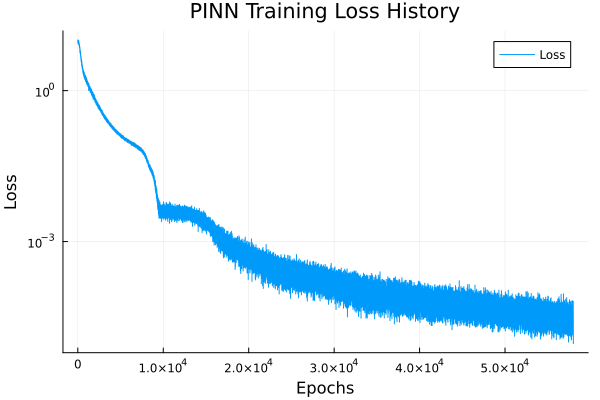

In [ ]:
# ---------------------------------------------------------------
# 1. Generalized PINN Functions (Accepting Arbitrary Weights)
# ---------------------------------------------------------------

# FIX 3: Harmonized Policy function ensuring Float64 execution mirrors training logic
function get_pinn_policy(x_val, weights, discretization, p)
    x = Float64(x_val)
    # Prevent division by zero if evaluation hits exactly 0.0
    x_safe = max(x, 1e-4) 
    
    cpu_weights = weights |> cpu
    V_func(x_in) = first(discretization.phi([x_in], cpu_weights))
    
    Vx_val = ForwardDiff.derivative(V_func, x_safe)
    
    denom = p.α * x_safe
    arg = Vx_val / denom
    
    # Mirror the exact absolute value trick used in training
    arg_safe = 0.5 * (arg + abs(arg)) + 1e-7
    raw_u = -(1.0 / p.α) * log(arg_safe)
    
    return 0.5 * (raw_u + abs(raw_u))
end

# FIX 3: Harmonized Evaluation Residual
function hjb_res_pinn_at(x::Float64, weights, discretization, p)
    x_safe = max(x, 1e-4)
    cpu_weights = weights |> cpu
    
    function Vfn(x_)
        return first(discretization.phi([x_], cpu_weights))
    end
    
    Vx_val  = ForwardDiff.derivative(Vfn, x_safe)
    Vxx_val = ForwardDiff.derivative(x_ -> ForwardDiff.derivative(Vfn, x_), x_safe)
    
    denom = p.α * x_safe
    arg = Vx_val / denom
    
    arg_safe = 0.5 * (arg + abs(arg)) + 1e-7
    raw_u = -(1.0 / p.α) * log(arg_safe)
    u = 0.5 * (raw_u + abs(raw_u))
    
    lhs = p.ρ * Vfn(x_safe)
    rhs = x_safe * (1 - exp(-p.α * u)) + (p.r * x_safe - u) * Vx_val + 0.5 * p.σ^2 * x_safe^2 * Vxx_val
    
    return abs(lhs - rhs)
end

# Define milestones outside
checkpoint_milestones = [1000, 5000, 10000, 20000, 25000, 50000, 1000000]

function run_incremental_training(params)
    r_val = Float32(params.r)
    σ_val = Float32(params.σ)
    ρ_val = Float32(params.ρ)
    α_val = Float32(params.α)
    
    # FIX 1: Expand domain to match your 1001-element evaluation vector [0, 10]
    # We use 0.01 instead of 0.0 to prevent 1/x division by zero errors
    x_min, x_max = 0.01f0, 10.0f0 
    
    @parameters x
    @variables V(..)
    Dx, Dxx = Differential(x), Differential(x)^2
    V_x = Dx(V(x))

    arg = V_x / (α_val * x)
    arg_safe = 0.5f0 * (arg + abs(arg)) + 1f-7
    raw_u = -(1.0f0 / α_val) * log(arg_safe)
    u_star = 0.5f0 * (raw_u + abs(raw_u))

    # FIX 2: Soft algebraic penalty that is 0 when V_x > 0, 
    # but scales quadratically if V_x goes negative.
    gradient_penalty = 500.0f0 * (V_x - abs(V_x))^2

    # Inject the penalty into the PDE system
    eq = -ρ_val * V(x) + x * (1.0f0 - exp(-α_val * u_star)) + 
          V_x * (r_val * x - u_star) + 0.5f0 * σ_val^2 * x^2 * Dxx(V(x)) + gradient_penalty ~ 0.0f0

    domains = [x ∈ Interval(x_min, x_max)]
    bcs = [V(x_min) ~ 0.0f0, Dx(V(x_max)) ~ 1.0f0]

    @named pde_system = PDESystem(eq, bcs, domains, [x], [V(x)])

    inner_size = 32
    chain = Lux.Chain(
        Lux.Dense(1, inner_size, Lux.tanh),
        Lux.Dense(inner_size, inner_size, Lux.tanh),
        Lux.Dense(inner_size, 1, Lux.identity) 
    )

    rng = Random.default_rng()
    ps, st = Lux.setup(rng, chain)
    ps = ComponentArray(ps) .* 0.01f0 
    ps_gpu = ps |> Lux.f32 |> gpu

    strategy = StochasticTraining(500)
    discretization = PhysicsInformedNN(chain, strategy, init_params = ps_gpu)
    prob = discretize(pde_system, discretization)
    opt = OptimizationOptimisers.Adam(1e-4)

    total_epochs = Ref(0) 
    pinn_checkpoints = Dict{Int, Any}()
    pinn_plotting = Dict{Int, Any}() 
    loss_history = Float64[]

    cb = function (state, loss, _...)
        total_epochs[] += 1
        current_epoch = total_epochs[] 
        push!(loss_history, loss)

        if isnan(loss) || isinf(loss)
            @warn "Epoch $(current_epoch): NaN/Inf loss encountered!"
            return true 
        end

        if current_epoch in checkpoint_milestones
            println(" > Milestone reached: Epoch $(current_epoch) | Loss: $loss")
            pinn_checkpoints[current_epoch] = copy(state.u) |> cpu
        end

        if loss < 1e-5
            println(" ✓ Convergence achieved at epoch $(current_epoch)! Loss ($loss) < 1e-5. Halting.")
            pinn_checkpoints[current_epoch] = copy(state.u) |> cpu
            return true 
        end

        if current_epoch % 1000 == 0
            pinn_plotting[current_epoch] = copy(state.u) |> cpu
        end

        return false 
    end

    println("Starting PINN training analysis...")
    res = Optimization.solve(prob, opt; maxiters = checkpoint_milestones[end], callback = cb)
    return discretization, pinn_checkpoints, pinn_plotting, loss_history, res
end

# Execution
discretization, pinn_checkpoints, pinn_plotting, loss_history, res = run_incremental_training(params)
plot(loss_history, title="PINN Training Loss History", xlabel="Epochs", ylabel="Loss", yscale=:log10, label="Loss")

Epoch 1000 | Mean Absolute HJB Residual: 1.663138
Epoch 5000 | Mean Absolute HJB Residual: 0.664679
Epoch 10000 | Mean Absolute HJB Residual: 0.632802
Epoch 20000 | Mean Absolute HJB Residual: 3.239465
Epoch 25000 | Mean Absolute HJB Residual: 5.009273
Epoch 50000 | Mean Absolute HJB Residual: 9.289615
Epoch 57994 | Mean Absolute HJB Residual: 10.005137
ADP Baseline | Mean Absolute HJB Residual: 0.000855


┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [Matrix{Float64}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl C:\Users\kavin\.julia\packages\LuxLib\zPBrt\src\impl\matmul.jl:194


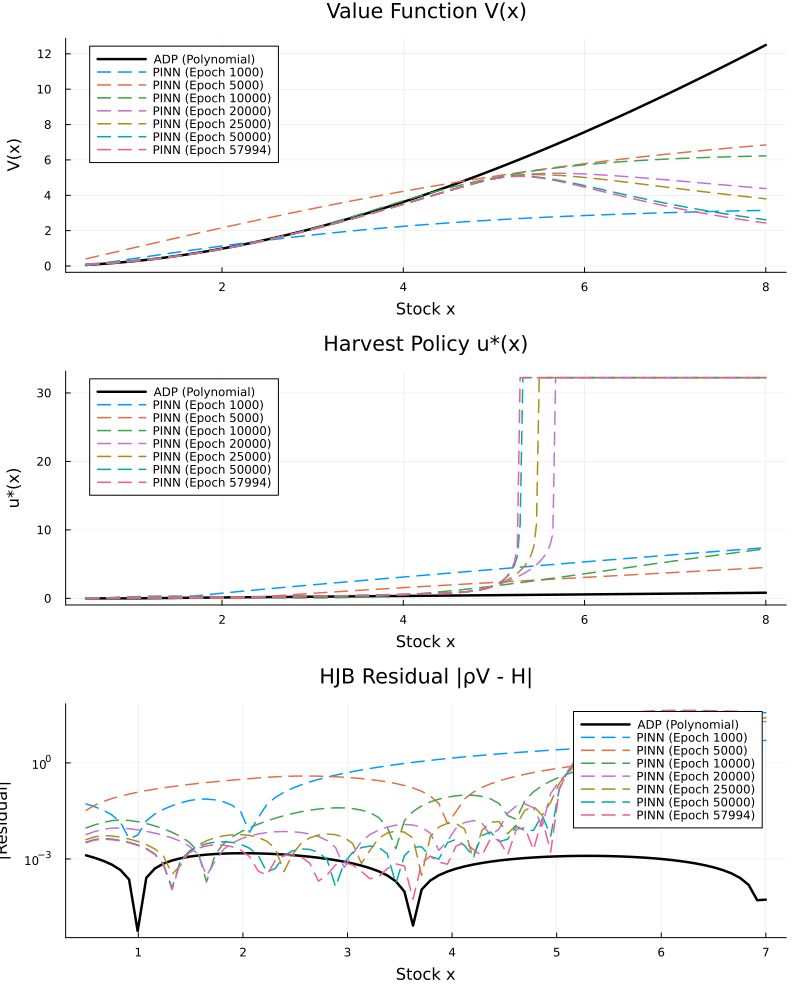

In [10]:
# Grids for plots and residual analysis
xplot_c = collect(range(0.5, 8.0, length=250))
xtest   = collect(range(0.5, 7.0, length=80))

# Pre-allocate subplots
p_val = plot(title="Value Function V(x)", xlabel="Stock x", ylabel="V(x)", legend=:topleft, lw=2)
p_pol = plot(title="Harvest Policy u*(x)", xlabel="Stock x", ylabel="u*(x)", legend=:topleft, lw=2)
p_hjb = plot(title="HJB Residual |ρV - H|", xlabel="Stock x", ylabel="|Residual|", legend=:topright, lw=2, yscale=:log10)

# --- Plot ADP Benchmark ---
# (Assumes V(x, theta_opt), policy(x, theta_opt, α), and hjb_residual are in scope)
adp_policy_fn(x) = clamp(Float64(policy(x, theta_opt, params.α)), 0.0, Inf)
adp_hjb_vec = [abs(hjb_residual(x, theta_opt, params)) for x in xtest]

plot!(p_val, xplot_c, [V(x, theta_opt) for x in xplot_c], label="ADP (Polynomial)", lw=2.5, color=:black, ls=:solid)
plot!(p_pol, xplot_c, adp_policy_fn.(xplot_c), label="ADP (Polynomial)", lw=2.5, color=:black, ls=:solid)
plot!(p_hjb, xtest, adp_hjb_vec, label="ADP (Polynomial)", lw=2.5, color=:black, ls=:solid)

# --- Plot PINN Checkpoints ---

available_epochs = sort(collect(keys(pinn_checkpoints)))

if isempty(available_epochs)
    @warn "No PINN checkpoints were stored; skipping PINN overlay plots."
else
    for (idx, epoch) in enumerate(available_epochs)
        w = pinn_checkpoints[epoch]
        
        # 1. Value Function
        v_vals = [Float64(first(discretization.phi([x], w))) for x in xplot_c]
        plot!(p_val, xplot_c, v_vals, label="PINN (Epoch $epoch)", lw=1.5, color=idx, ls=:dash)
        
        # 2. Policy
        pol_vals = [get_pinn_policy(x, w, discretization, params) for x in xplot_c]
        plot!(p_pol, xplot_c, pol_vals, label="PINN (Epoch $epoch)", lw=1.5, color=idx, ls=:dash)
            
        # 3. Residuals
        res_vals = [hjb_res_pinn_at(x, w, discretization, params) for x in xtest]
        plot!(p_hjb, xtest, res_vals, label="PINN (Epoch $epoch)", lw=1.5, color=idx, ls=:dash)
        
        # Print Mean Residual Summary to console
        mean_res = mean(res_vals)
        @printf "Epoch %4d | Mean Absolute HJB Residual: %.6f\n" epoch mean_res
    end
end

# Print baseline for context
@printf "ADP Baseline | Mean Absolute HJB Residual: %.6f\n" mean(adp_hjb_vec)

# Combine into a final summary layout
plot(p_val, p_pol, p_hjb, layout=(3, 1), size=(800, 1000))

In [11]:
using JLD2

@save "pinn_training_results.jld2" discretization pinn_checkpoints pinn_plotting loss_history res

┌ Warning: Attempting to store NeuralPDE.var"#full_loss_function#get_likelihood_estimate_function##1"{Returns{Nothing}, NeuralPDE.PINNRepresentation, Int64, Bool, Base.RefValue{Int64}, NeuralPDE.Phi{StatefulLuxLayer{Val{true}, Lux.Chain{@NamedTuple{layer_1::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Lux.Dense{typeof(tanh), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Lux.Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, Nothing, @NamedTuple{layer_1::@NamedTuple{}, layer_2::@NamedTuple{}, layer_3::@NamedTuple{}}}}, Nothing, Bool}.
│ JLD2 only stores functions by name.
│  This may not be useful for anonymous functions.
└ @ JLD2 C:\Users\kavin\.julia\packages\JLD2\qcxKY\src\data\writing_datatypes.jl:447
┌ Warning: Attempting to store OptimizationZygoteExt.var"#grad#16"{SciMLBase.NullParameters, OptimizationFunction{true, AutoZygote, NeuralPDE.var"#full_loss_function#get_likelihood_estimate_function##1"{Returns{No